In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import json

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

Cargar el dataset procesado

In [2]:
DATA_PATH = Path("../data/processed/customer_support_tickets_processed.csv")

df = pd.read_csv(DATA_PATH)

print("Dimensiones del dataset procesado:")
print(df.shape)

df[["processed_text", "Ticket Type"]].head()

Dimensiones del dataset procesado:
(8469, 22)


,processed_text,Ticket Type
0,product setup have issue assist billing zip co...,Technical issue
1,peripheral compatibility have issue assist nee...,Technical issue
2,network problem face problem turn work fine ye...,Technical issue
3,account access have issue assist problem inter...,Billing inquiry
4,data loss have issue assist note seller respon...,Billing inquiry


Selección de variables

In [ ]:
X = df["processed_text"]
y = df["Ticket Subject"]
# y = df["Ticket Type"]

print("Cantidad de textos:", X.shape[0])
print("Cantidad de etiquetas:", y.shape[0])
print("\nDistribución de clases:")
print(y.value_counts())

Cantidad de textos: 8469
Cantidad de etiquetas: 8469

Distribución de clases:
Ticket Subject
Refund request              576
Software bug                574
Product compatibility       567
Delivery problem            561
Hardware issue              547
Battery life                542
Network problem             539
Installation support        530
Product setup               529
Payment issue               526
Product recommendation      517
Account access              509
Peripheral compatibility    496
Data loss                   491
Cancellation request        487
Display issue               478
Name: count, dtype: int64


División en entrenamiento y prueba

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)
print("\nDistribución en entrenamiento:")
print(y_train.value_counts())

print("\nDistribución en prueba:")
print(y_test.value_counts())

Entrenamiento: (6775,)
Prueba: (1694,)

Distribución en entrenamiento:
Ticket Subject
Refund request              461
Software bug                459
Product compatibility       453
Delivery problem            449
Hardware issue              437
Battery life                434
Network problem             431
Installation support        424
Product setup               423
Payment issue               421
Product recommendation      414
Account access              407
Peripheral compatibility    397
Data loss                   393
Cancellation request        390
Display issue               382
Name: count, dtype: int64

Distribución en prueba:
Ticket Subject
Software bug                115
Refund request              115
Product compatibility       114
Delivery problem            112
Hardware issue              110
Network problem             108
Battery life                108
Installation support        106
Product setup               106
Payment issue               105
Product recommen

Vectorización TF-IDF

In [28]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Dimensión matriz entrenamiento:", X_train_tfidf.shape)
print("Dimensión matriz prueba:", X_test_tfidf.shape)

Dimensión matriz entrenamiento: (6775, 5000)
Dimensión matriz prueba: (1694, 5000)


Entrenamiento del modelo

In [29]:
model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train_tfidf, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

Predicciones

In [30]:
y_pred = model.predict(X_test_tfidf)

y_pred[:10]

array(['Software bug', 'Hardware issue', 'Product compatibility',
       'Hardware issue', 'Account access', 'Installation support',
       'Display issue', 'Network problem', 'Display issue',
       'Product recommendation'], dtype=object)

 Cálculo de métricas generales

In [31]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

metrics = {
    "accuracy": accuracy,
    "precision_weighted": precision,
    "recall_weighted": recall,
    "f1_weighted": f1
}

metrics

{'accuracy': 0.9970484061393152,
 'precision_weighted': 0.9970755316786317,
 'recall_weighted': 0.9970484061393152,
 'f1_weighted': 0.9970508237859942}

 Reporte de clasificación por clase

In [32]:
report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
Account access,1.000000,1.000000,1.000000,102.000000
Battery life,1.000000,1.000000,1.000000,108.000000
Cancellation request,1.000000,1.000000,1.000000,97.000000
Data loss,0.989899,1.000000,0.994924,98.000000
Delivery problem,1.000000,1.000000,1.000000,112.000000
Display issue,1.000000,0.989583,0.994764,96.000000
Hardware issue,1.000000,1.000000,1.000000,110.000000
Installation support,1.000000,1.000000,1.000000,106.000000
Network problem,0.990826,1.000000,0.995392,108.000000
Payment issue,0.990566,1.000000,0.995261,105.000000


Matriz de confusión

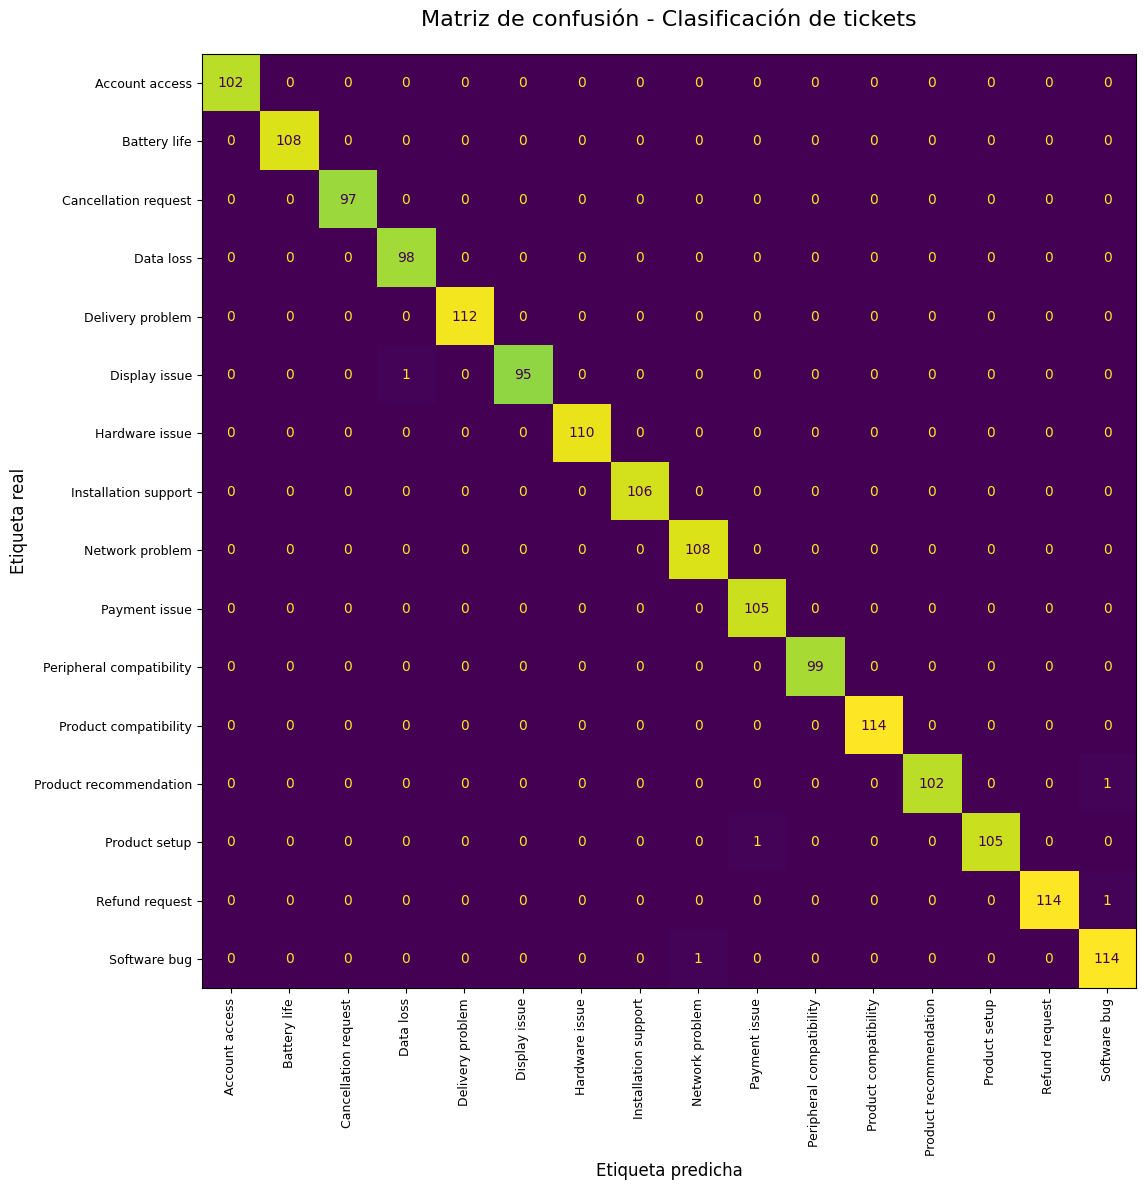

In [45]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=model.classes_
)

fig, ax = plt.subplots(figsize=(14, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    values_format="d",
    colorbar=False
)

plt.title(
    "Matriz de confusión - Clasificación de tickets",
    fontsize=16,
    pad=20
)

plt.xlabel("Etiqueta predicha", fontsize=12)
plt.ylabel("Etiqueta real", fontsize=12)

ax.tick_params(
    axis="x",
    labelsize=9
)

ax.tick_params(
    axis="y",
    labelsize=9
)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/matriz_confusion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Guardado de métricas

In [34]:
with open("../outputs/reports/metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

report_df.to_csv("../outputs/reports/classification_report.csv")

print("Métricas guardadas correctamente.")

Métricas guardadas correctamente.


Guardado del modelo entrenado

In [35]:
pipeline_artifacts = {
    "tfidf": tfidf,
    "model": model
}

joblib.dump(
    pipeline_artifacts,
    "../models/tfidf_logistic_regression_model.pkl"
)

print("Modelo guardado correctamente.")

Modelo guardado correctamente.


In [42]:
feature_names = tfidf.get_feature_names_out()

for idx, class_name in enumerate(model.classes_):

    top_features = sorted(
        zip(model.coef_[idx], feature_names),
        reverse=True
    )[:10]

    print("\n")
    print("=" * 60)
    print(class_name)
    print("=" * 60)

    for score, word in top_features:
        print(word)



Account access
relate
face
life
purchase
notice
network
have
loss
issue
hardware


Battery life
account
troubleshoot
problem
persist
device
customer
contact
datum
bug
try


Cancellation request
software
problem
persist
say
start
use
ve
customer
access
bug


Data loss
request
didn
update
find
try
step
available
product
check
use


Delivery problem
find
account
use
request
start
need
product
problem
persist
assist


Display issue
troubleshoot
data
update
datum
persist
ve
thank
need
compatibility
problem


Hardware issue
find
compatibility
account
step
ve
time
support
unable
check
need


Installation support
find
time
support
perform
contact
check
error
didn
assist
available


Network problem
find
work
support
step
request
unable
device
available
datum
perform


Payment issue
request
problem
persist
use
find
device
need
thank
unable
check


Peripheral compatibility
start
request
find
error
work
software
ve
didn
option
say


Product compatibility
time
resolve
update
request
thank
unable
